In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

print(f"pandas:  {pd.__version__}")
print(f"numpy:   {np.__version__}")

pandas:  3.0.1
numpy:   2.4.3


In [51]:
# Load clean train and test sets

df_train = pd.read_pickle("../data/processed/df_train.pkl")
df_test  = pd.read_pickle("../data/processed/df_test.pkl")
df = pd.read_pickle("../data/processed/df_resolved.pkl")

print(f"{'Dataset':<12} {'Rows':>10} {'Columns':>10} {'Default Rate':>14}")
print("─" * 50)
for name, d in [("df_train", df_train), ("df_test", df_test)]:
    print(f"{name:<12} {len(d):>10,} {d.shape[1]:>10} "
          f"{d['default_flag'].mean()*100:>13.2f}%")

print()
print("Feature dtypes:")
print(df_train.dtypes.value_counts())

Dataset            Rows    Columns   Default Rate
──────────────────────────────────────────────────
df_train        829,355         68         18.46%
df_test         518,744         68         22.42%

Feature dtypes:
float64    55
str        10
int64       2
int32       1
Name: count, dtype: int64


## Objective

1. Calculate Information Value (IV) for all features to identify
   which carry predictive signal worth encoding
2. Bin numeric features into monotonic WoE bins
3. Encode all selected features with Weight of Evidence (WoE)
4. Produce final WoE-encoded train and test sets for modelling

All WoE parameters are fitted on df_train only and applied to
df_test without refitting — this prevents data leakage from the
test period into the encoding step.

In [52]:
# Define feature lists by type

numeric_features = [
    "loan_amnt", "int_rate", "installment", "dti",
    "fico_range_low", "inq_last_6mths", "open_acc", "pub_rec",
    "revol_bal", "revol_util", "total_acc", "mort_acc",
    "delinq_2yrs", "mths_since_last_delinq", "mths_since_recent_inq",
    "log_annual_inc", "ever_delinq"
]

categorical_features = [
    "grade", "sub_grade", "term", "purpose",
    "verification_status", "home_ownership", "emp_length"
]

target = "default_flag"

In [53]:
# Confirm all features present in df_train
missing_num = [f for f in numeric_features if f not in df_train.columns]
missing_cat = [f for f in categorical_features if f not in df_train.columns]

print(f"Numeric features:     {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Missing from df_train: {missing_num + missing_cat}")

Numeric features:     17
Categorical features: 7
Missing from df_train: []


### Weight of Evidence (WoE) and Information Value (IV)

---

#### Why WoE encoding for this project?

Logistic regression assumes a linear relationship between each feature and
the log-odds of default. In practice, most credit risk features are non-linear
— for example, the relationship between DTI and default risk is not a straight
line. WoE encoding solves this by converting every feature into log-odds space
directly, satisfying the linearity assumption by construction.

Additional benefits:
- Handles outliers naturally through binning
- Works consistently for both numeric and categorical features
- Missing values can be assigned their own bin
- Produces interpretable coefficients in the final scorecard

---

#### Calculation

For each bin of a feature:
```
WoE = ln(Distribution of Events / Distribution of Non-Events)
    = ln(% of Defaults in bin / % of Non-Defaults in bin)
```

Information Value summarises total predictive power across all bins:
```
IV = Σ (Distribution of Events − Distribution of Non-Events) × WoE
```

---

#### IV Interpretation

| IV Range | Predictive Power | Action |
|----------|-----------------|--------|
| < 0.02 | Useless | Drop |
| 0.02 – 0.10 | Weak | Review |
| 0.10 – 0.30 | Medium | Keep |
| 0.30 – 0.50 | Strong | Keep |
| > 0.50 | Suspicious | Check for leakage |

---

#### Implementation Notes

**`calculate_woe_iv()`** — calculates WoE and IV for a single feature.
- Numeric features: binned into quantile-based buckets (equal frequency),
  which ensures sufficient observations in each bin
- Categorical features: raw categories used as bins directly
- Distributions clipped at 1e-9 to avoid log(0) errors

**`calculate_all_iv()`** — applies `calculate_woe_iv()` across all features
and returns a summary table ranked by IV descending. Fitted on df_train only —
WoE parameters are never refit on df_test to prevent leakage.

In [54]:
# WoE and IV calculation functions

def calculate_woe_iv(df, feature, target, bins=10, categorical=False):
    df_ = df[[feature, target]].copy()

    if categorical:
        df_["bin"] = df_[feature].astype(str)
    else:
        try:
            df_["bin"] = pd.qcut(
                df_[feature], q=bins, duplicates="drop"
            )
        except Exception:
            df_["bin"] = pd.cut(
                df_[feature], bins=bins, duplicates="drop"
            )

    total_events     = df_[target].sum()
    total_nonevents  = (df_[target] == 0).sum()

    grouped = df_.groupby("bin")[target].agg(
        events    = "sum",
        total     = "count"
    ).reset_index()

    grouped["nonevents"]      = grouped["total"] - grouped["events"]
    grouped["dist_events"]    = grouped["events"]    / total_events
    grouped["dist_nonevents"] = grouped["nonevents"] / total_nonevents

    # Clip to avoid log(0)
    grouped["dist_events"]    = grouped["dist_events"].clip(lower=1e-9)
    grouped["dist_nonevents"] = grouped["dist_nonevents"].clip(lower=1e-9)

    grouped["woe"] = np.log(
        grouped["dist_events"] / grouped["dist_nonevents"]
    )
    grouped["iv_bin"] = (
        grouped["dist_events"] - grouped["dist_nonevents"]
    ) * grouped["woe"]

    iv = grouped["iv_bin"].sum()

    grouped["event_rate"] = (
        grouped["events"] / grouped["total"] * 100
    ).round(2)
    grouped["feature"] = feature

    return grouped[["feature", "bin", "total", "events",
                     "nonevents", "event_rate", "woe", "iv_bin"]], iv


def calculate_all_iv(df, numeric_features, categorical_features, target, bins=10):
    results = []
    for feature in numeric_features:
        _, iv = calculate_woe_iv(df, feature, target,
                                  bins=bins, categorical=False)
        results.append({"feature": feature, "type": "numeric", "iv": round(iv, 4)})

    for feature in categorical_features:
        _, iv = calculate_woe_iv(df, feature, target,
                                  bins=bins, categorical=True)
        results.append({"feature": feature, "type": "categorical", "iv": round(iv, 4)})

    iv_df = pd.DataFrame(results).sort_values("iv", ascending=False).reset_index(drop=True)
    return iv_df

In [55]:
# Calculate IV for all features on training set only

iv_summary = calculate_all_iv(
    df       = df_train,
    numeric_features     = numeric_features,
    categorical_features = categorical_features,
    target   = target,
    bins     = 10
)

print("Feature IV Summary — ranked by predictive power:")
print()
print(f"{'Feature':<30} {'Type':<12} {'IV':>8}  {'Strength'}")
print("─" * 65)

def iv_strength(iv):
    if iv < 0.02:   return "Useless"
    elif iv < 0.10: return "Weak"
    elif iv < 0.30: return "Medium"
    elif iv < 0.50: return "Strong"
    else:           return "Suspicious"

for _, row in iv_summary.iterrows():
    print(f"{row['feature']:<30} {row['type']:<12} {row['iv']:>8.4f}  {iv_strength(row['iv'])}")

Feature IV Summary — ranked by predictive power:

Feature                        Type               IV  Strength
─────────────────────────────────────────────────────────────────
sub_grade                      categorical    0.5067  Suspicious
grade                          categorical    0.4715  Strong
int_rate                       numeric        0.4531  Strong
term                           categorical    0.2382  Medium
fico_range_low                 numeric        0.1193  Medium
dti                            numeric        0.0738  Weak
verification_status            categorical    0.0498  Weak
mths_since_recent_inq          numeric        0.0371  Weak
loan_amnt                      numeric        0.0361  Weak
log_annual_inc                 numeric        0.0312  Weak
installment                    numeric        0.0253  Weak
revol_util                     numeric        0.0221  Weak
purpose                        categorical    0.0210  Weak
home_ownership                 categoric

In [64]:
# Recalculate IV for binary and zero-inflated features
# These were incorrectly binned with quantile binning in the original IV calculation
# Binary variables and zero-inflated counts should use categorical=True

recheck_features = {
    "ever_delinq"           : True,   # binary 0/1
    "delinq_2yrs"           : True,   # zero-inflated, split 0 vs >0
    "pub_rec"               : True,   # zero-inflated, split 0 vs >0
    "open_acc"              : False,  # recheck with fewer bins
    "total_acc"             : False,  # recheck with fewer bins
    "revol_bal"             : False,  # recheck with fewer bins
    "mths_since_last_delinq": False,  # recheck — was 50.4% missing, now sentinel 999
}

print(f"{'Feature':<30} {'IV (original)':>14} {'IV (recheck)':>14} {'Change':>10}")
print("─" * 72)

original_ivs = {
    "ever_delinq"           : 0.0000,
    "delinq_2yrs"           : 0.0013,
    "pub_rec"               : 0.0010,
    "open_acc"              : 0.0077,
    "total_acc"             : 0.0004,
    "revol_bal"             : 0.0034,
    "mths_since_last_delinq": 0.0015,
}

for feature, is_cat in recheck_features.items():
    # For zero-inflated counts, create binary version
    if feature in ["delinq_2yrs", "pub_rec", "open_acc",
                   "total_acc", "revol_bal"]:
        temp_col = f"{feature}_bin"
        df_train[temp_col] = (df_train[feature] > 0).astype(str)
        _, iv_new = calculate_woe_iv(
            df_train, temp_col, target, categorical=True
        )
        df_train.drop(columns=[temp_col], inplace=True)
    else:
        _, iv_new = calculate_woe_iv(
            df_train, feature, target,
            bins=10, categorical=is_cat
        )

    iv_orig   = original_ivs[feature]
    iv_change = iv_new - iv_orig
    flag      = " ← improved" if iv_new > 0.02 else ""
    print(f"{feature:<30} {iv_orig:>14.4f} {iv_new:>14.4f} "
          f"{iv_change:>+10.4f}{flag}")

Feature                         IV (original)   IV (recheck)     Change
────────────────────────────────────────────────────────────────────────
ever_delinq                            0.0000         0.0018    +0.0018
delinq_2yrs                            0.0013         0.0012    -0.0001
pub_rec                                0.0010         0.0051    +0.0041
open_acc                               0.0077         0.0000    -0.0077
total_acc                              0.0004         0.0000    -0.0004
revol_bal                              0.0034         0.0001    -0.0033
mths_since_last_delinq                 0.0015         0.0015    +0.0000


In [56]:
# Feature selection based on IV

# Drop — redundant with sub_grade
drop_redundant = ["grade", "int_rate"]

# Drop — IV below 0.02 (useless after binning)
drop_low_iv = [
    "open_acc", "emp_length", "revol_bal",
    "mths_since_last_delinq", "delinq_2yrs",
    "pub_rec", "total_acc", "ever_delinq"
]

# Final selected features
selected_numeric = [
    f for f in numeric_features
    if f not in drop_redundant + drop_low_iv
]

selected_categorical = [
    f for f in categorical_features
    if f not in drop_redundant + drop_low_iv
]

print("Selected numeric features:")
for f in selected_numeric:
    iv = iv_summary[iv_summary["feature"] == f]["iv"].values[0]
    print(f"  {f:<30} IV: {iv:.4f}")

print()
print("Selected categorical features:")
for f in selected_categorical:
    iv = iv_summary[iv_summary["feature"] == f]["iv"].values[0]
    print(f"  {f:<30} IV: {iv:.4f}")

print()
print(f"Total features selected: {len(selected_numeric) + len(selected_categorical)}")

Selected numeric features:
  loan_amnt                      IV: 0.0361
  installment                    IV: 0.0253
  dti                            IV: 0.0738
  fico_range_low                 IV: 0.1193
  inq_last_6mths                 IV: 0.0191
  revol_util                     IV: 0.0221
  mort_acc                       IV: 0.0192
  mths_since_recent_inq          IV: 0.0371
  log_annual_inc                 IV: 0.0312

Selected categorical features:
  sub_grade                      IV: 0.5067
  term                           IV: 0.2382
  purpose                        IV: 0.0210
  verification_status            IV: 0.0498
  home_ownership                 IV: 0.0207

Total features selected: 14


In [57]:
# Fit WoE bins on df_train only
# Store bin edges and WoE mappings for application to df_test

woe_mappings = {}  # stores WoE lookup per feature

def fit_woe(df, feature, target, bins=10, categorical=False):
    """
    Fits WoE bins on training data.
    Returns a mapping dict: {bin_label: woe_value}
    """
    woe_df, iv = calculate_woe_iv(
        df, feature, target, bins=bins, categorical=categorical
    )
    mapping = dict(zip(woe_df["bin"].astype(str), woe_df["woe"]))
    return mapping, woe_df, iv


def apply_woe_numeric(series, mapping, bins_used):
    """
    Applies fitted WoE bins to a numeric series.
    bins_used: the pd.IntervalIndex from training binning
    """
    binned = pd.cut(series, bins=bins_used, include_lowest=True)
    return binned.astype(str).map(mapping)


# Fit WoE on all selected features
bin_edges = {}  # store bin edges for numeric features

print("Fitting WoE on training set...")
print()
print(f"{'Feature':<30} {'Bins':>6} {'IV':>8}")
print("─" * 48)

for feature in selected_numeric:
    woe_df, iv = calculate_woe_iv(
        df_train, feature, target, bins=10, categorical=False
    )
    # Extract bin edges from the interval index
    bins_used = pd.IntervalIndex(
        pd.qcut(df_train[feature], q=10, duplicates="drop").cat.categories
    )
    mapping = dict(zip(woe_df["bin"].astype(str), woe_df["woe"]))
    woe_mappings[feature] = mapping
    bin_edges[feature]    = bins_used
    print(f"{feature:<30} {len(mapping):>6} {iv:>8.4f}")

for feature in selected_categorical:
    woe_df, iv = calculate_woe_iv(
        df_train, feature, target, bins=10, categorical=True
    )
    mapping = dict(zip(woe_df["bin"].astype(str), woe_df["woe"]))
    woe_mappings[feature] = mapping
    print(f"{feature:<30} {len(mapping):>6} {iv:>8.4f}")

print()
print(f"WoE mappings fitted for {len(woe_mappings)} features")

Fitting WoE on training set...

Feature                          Bins       IV
────────────────────────────────────────────────
loan_amnt                          10   0.0361
installment                        10   0.0253
dti                                10   0.0738
fico_range_low                     10   0.1193
inq_last_6mths                      3   0.0191
revol_util                         10   0.0221
mort_acc                            5   0.0192
mths_since_recent_inq               9   0.0371
log_annual_inc                     10   0.0312
sub_grade                          35   0.5067
term                                2   0.2382
purpose                            14   0.0210
verification_status                 3   0.0498
home_ownership                      4   0.0207

WoE mappings fitted for 14 features


In [58]:
# Apply WoE mappings to train and test sets

def apply_woe_all(df, selected_numeric, selected_categorical,
                  woe_mappings, bin_edges, target):
    """
    Applies fitted WoE mappings to a DataFrame.
    Returns a new DataFrame with WoE-encoded features + target.
    """
    df_woe = pd.DataFrame(index=df.index)
    df_woe[target] = df[target]

    # Numeric features — use fitted bin edges
    for feature in selected_numeric:
        binned = pd.cut(
            df[feature],
            bins=bin_edges[feature],
            include_lowest=True
        )
        df_woe[f"woe_{feature}"] = (
            binned.astype(str).map(woe_mappings[feature])
        )

    # Categorical features — direct category lookup
    for feature in selected_categorical:
        df_woe[f"woe_{feature}"] = (
            df[feature].astype(str).map(woe_mappings[feature])
        )

    return df_woe


df_train_woe = apply_woe_all(
    df_train, selected_numeric, selected_categorical,
    woe_mappings, bin_edges, target
)

df_test_woe = apply_woe_all(
    df_test, selected_numeric, selected_categorical,
    woe_mappings, bin_edges, target
)

print(f"df_train_woe shape: {df_train_woe.shape}")
print(f"df_test_woe shape:  {df_test_woe.shape}")
print()

# Check for nulls introduced by WoE mapping
# (unseen categories in test set would produce NaN)
train_nulls = df_train_woe.isnull().sum()
test_nulls  = df_test_woe.isnull().sum()

print("Nulls in df_train_woe:")
print(train_nulls[train_nulls > 0] if train_nulls.sum() > 0
      else "  None")
print()
print("Nulls in df_test_woe:")
print(test_nulls[test_nulls > 0] if test_nulls.sum() > 0
      else "  None")

df_train_woe shape: (829355, 15)
df_test_woe shape:  (518744, 15)

Nulls in df_train_woe:
  None

Nulls in df_test_woe:
woe_loan_amnt         9260
woe_installment        387
woe_dti                  2
woe_mort_acc             1
woe_log_annual_inc       3
dtype: int64


In [59]:
# Fill NaN WoE values with 0
# 0 = population average in WoE space — conservative imputation
# for test values falling outside training bin range

df_train_woe = df_train_woe.fillna(0)
df_test_woe  = df_test_woe.fillna(0)

# Confirm no nulls remain
print(f"Nulls in df_train_woe: {df_train_woe.isnull().sum().sum()}")
print(f"Nulls in df_test_woe:  {df_test_woe.isnull().sum().sum()}")
print()
print(f"df_train_woe shape: {df_train_woe.shape}")
print(f"df_test_woe shape:  {df_test_woe.shape}")
print()
print("Sample WoE-encoded features (first 3 rows):")
print(df_train_woe.head(3).to_string())

Nulls in df_train_woe: 0
Nulls in df_test_woe:  0

df_train_woe shape: (829355, 15)
df_test_woe shape:  (518744, 15)

Sample WoE-encoded features (first 3 rows):
   default_flag  woe_loan_amnt  woe_installment  woe_dti  woe_fico_range_low  woe_inq_last_6mths  woe_revol_util  woe_mort_acc  woe_mths_since_recent_inq  woe_log_annual_inc  woe_sub_grade  woe_term  woe_purpose  woe_verification_status  woe_home_ownership
0             0        -0.2827          -0.3641  -0.4142              0.2072             -0.0647         -0.1812        0.1013                     0.0655              0.0663         0.2791   -0.3341       0.0791                  -0.3679             -0.1478
1             0         0.1941           0.0619  -0.0772             -0.2804              0.3694         -0.3392       -0.2117                     0.2616              0.0106        -0.1032   -0.3341       0.5036                  -0.3679             -0.1478
2             0         0.1475           0.1407  -0.2478           

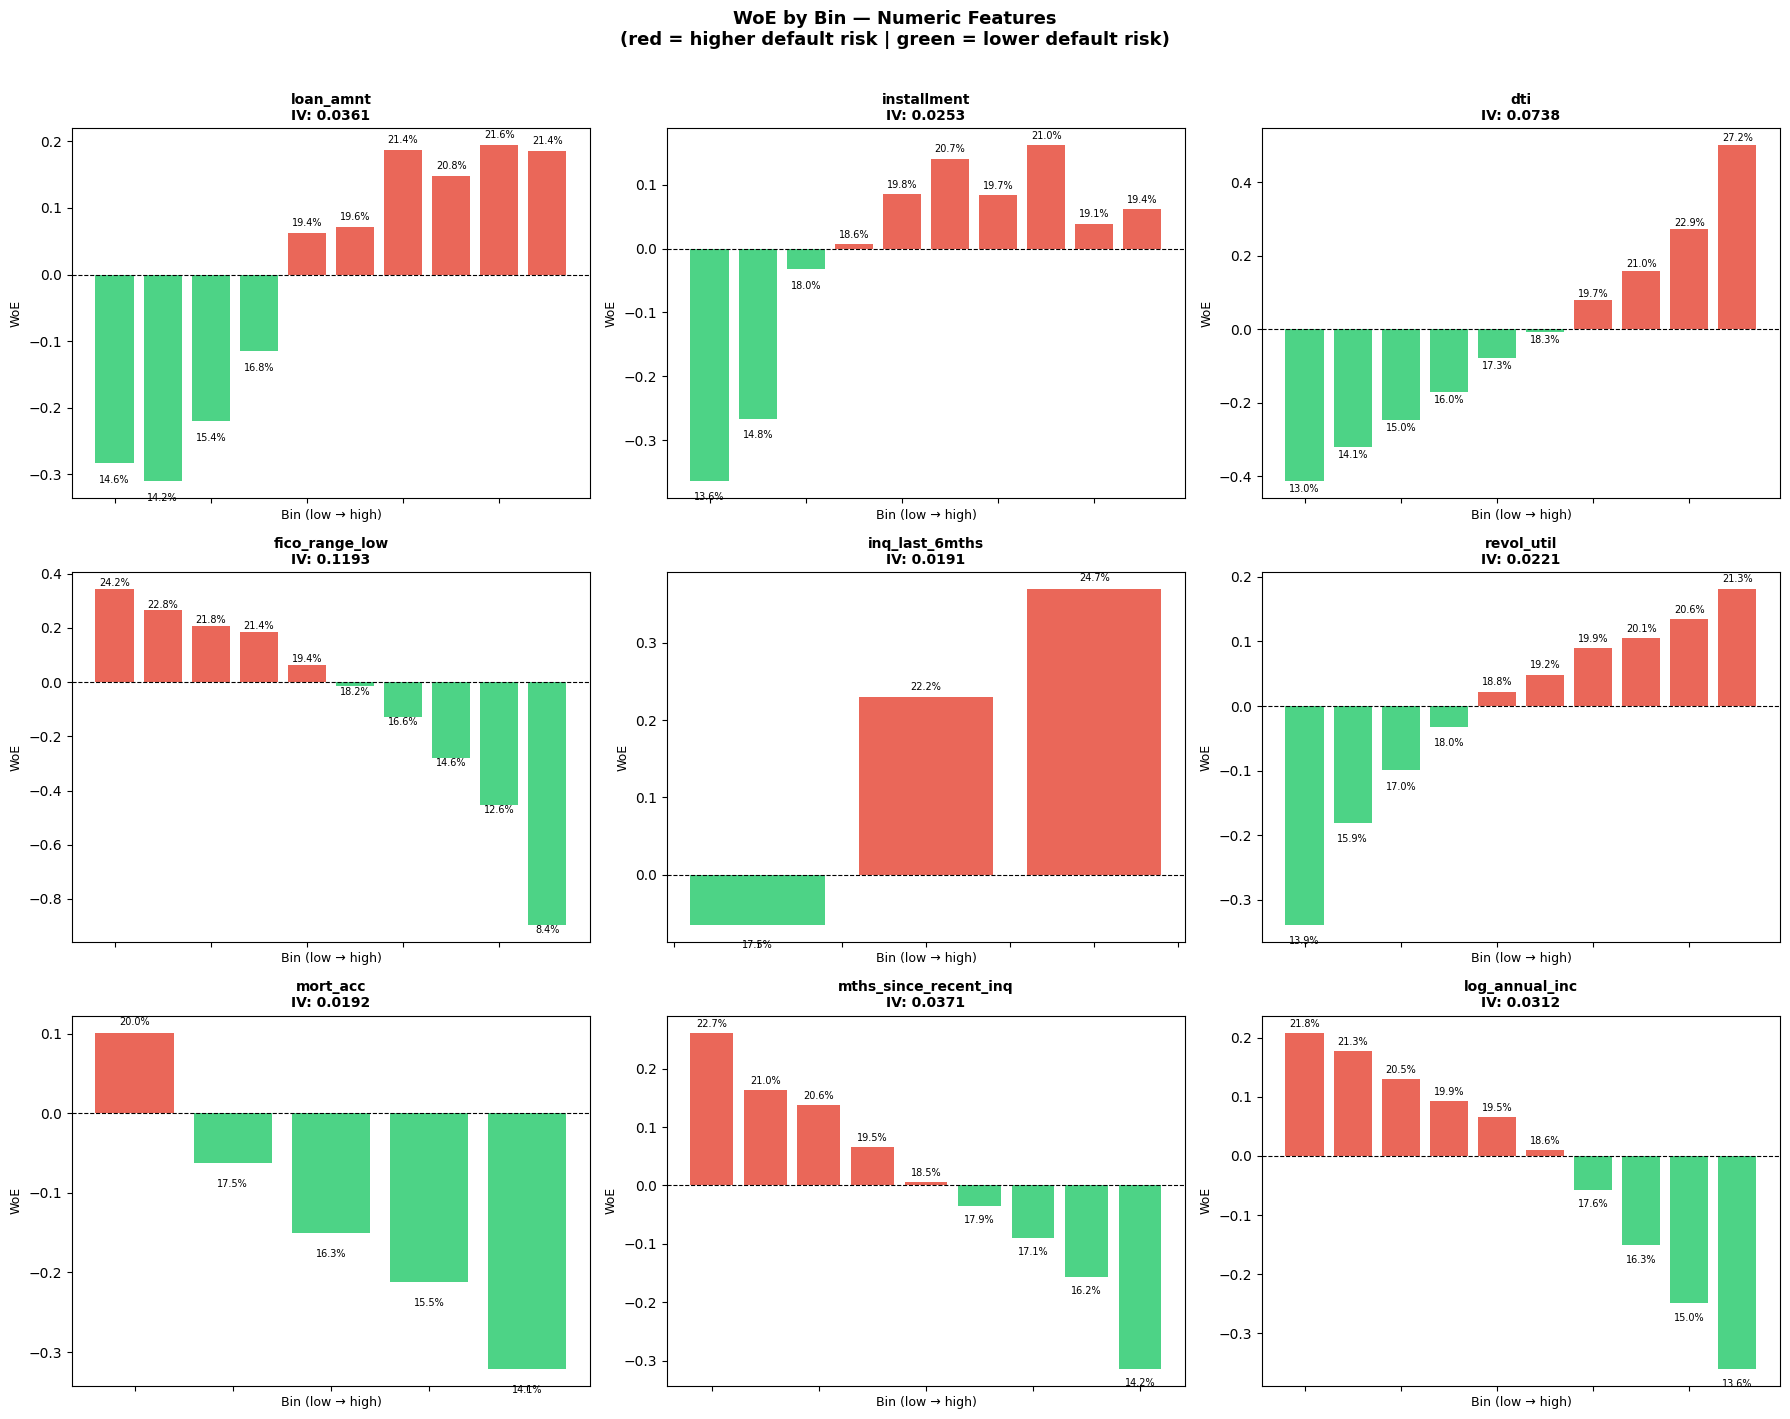

Saved: outputs/woe_numeric.png


In [60]:
# WoE monotonicity plots for numeric features

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, feature in enumerate(selected_numeric):
    woe_df, iv = calculate_woe_iv(
        df_train, feature, target, bins=10, categorical=False
    )
    woe_df = woe_df.sort_values("bin")

    ax = axes[i]
    ax.bar(range(len(woe_df)), woe_df["woe"],
           color=["#e74c3c" if w > 0 else "#2ecc71"
                  for w in woe_df["woe"]],
           alpha=0.85)
    ax.axhline(y=0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"{feature}\nIV: {iv:.4f}", fontsize=10, fontweight="bold")
    ax.set_ylabel("WoE", fontsize=9)
    ax.set_xlabel("Bin (low → high)", fontsize=9)
    ax.tick_params(axis="x", labelbottom=False)

    # Annotate event rate per bin
    for j, row in woe_df.iterrows():
        ax.text(list(range(len(woe_df)))[list(woe_df.index).index(j)],
                row["woe"] + 0.01 if row["woe"] >= 0 else row["woe"] - 0.03,
                f"{row['event_rate']:.1f}%",
                ha="center", fontsize=7)

plt.suptitle(
    "WoE by Bin — Numeric Features\n"
    "(red = higher default risk | green = lower default risk)",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("../outputs/woe_numeric.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/woe_numeric.png")

In [61]:
print(df_train["home_ownership"].value_counts())
print()
print("Default rate by home_ownership:")
print(df_train.groupby("home_ownership")["default_flag"].agg(
    count="count",
    defaults="sum",
    default_rate=lambda x: x.mean()*100
).round(2))

home_ownership
MORTGAGE    410712
RENT        336799
OWN          81609
OTHER          235
Name: count, dtype: int64

Default rate by home_ownership:
                 count  defaults  default_rate
home_ownership                                
MORTGAGE        410712     67089       16.3300
OTHER              235        46       19.5700
OWN              81609     15514       19.0100
RENT            336799     70416       20.9100


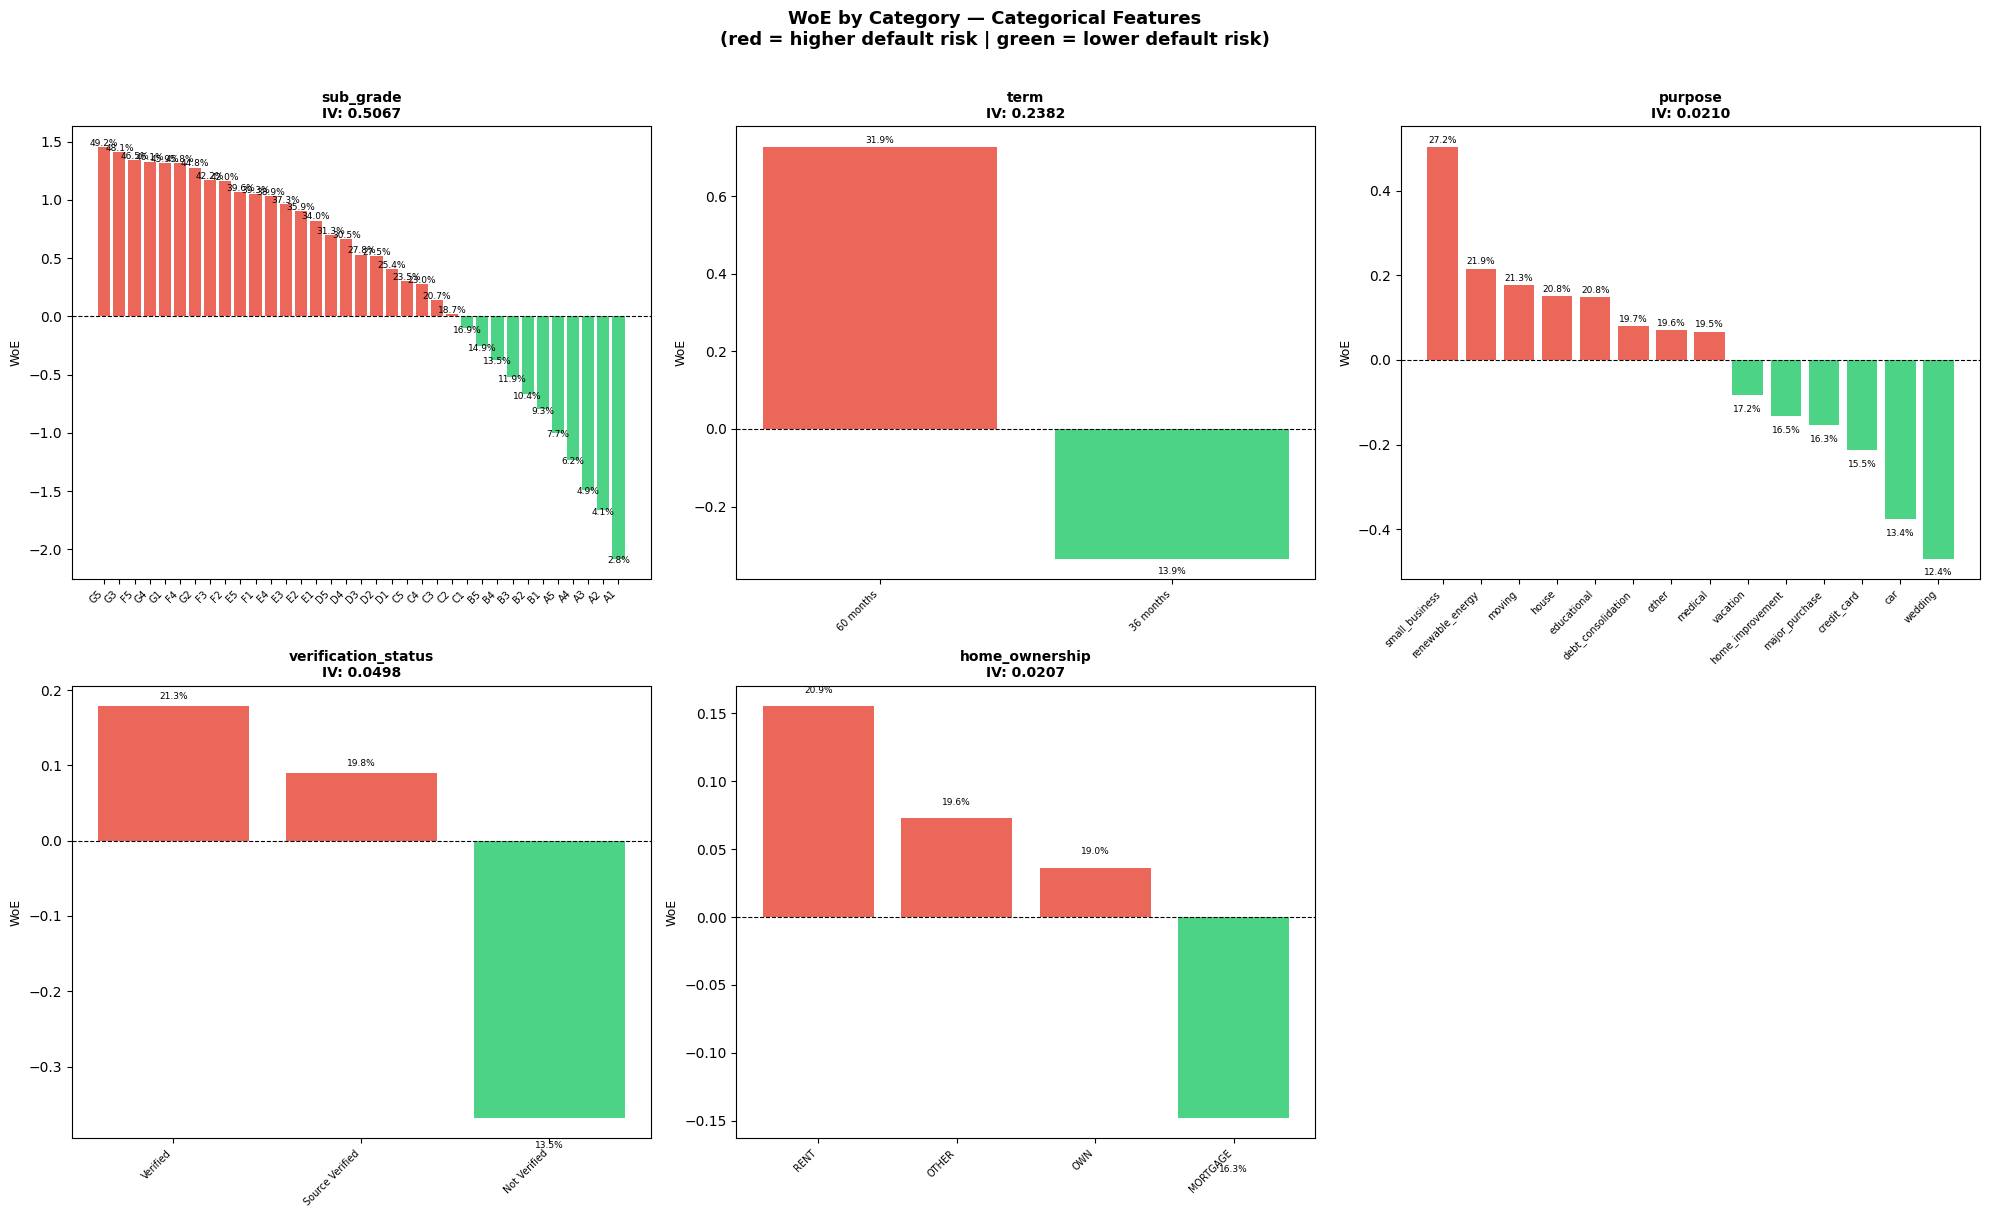

Saved: outputs/woe_categorical.png


In [62]:
# WoE plots for categorical features

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, feature in enumerate(selected_categorical):
    woe_df, iv = calculate_woe_iv(
        df_train, feature, target, bins=10, categorical=True
    )
    woe_df = woe_df.sort_values("woe", ascending=False)

    ax = axes[i]
    bars = ax.bar(
        range(len(woe_df)),
        woe_df["woe"],
        color=["#e74c3c" if w > 0 else "#2ecc71" for w in woe_df["woe"]],
        alpha=0.85
    )
    ax.axhline(y=0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"{feature}\nIV: {iv:.4f}", fontsize=10, fontweight="bold")
    ax.set_ylabel("WoE", fontsize=9)
    ax.set_xticks(range(len(woe_df)))
    ax.set_xticklabels(
        woe_df["bin"].astype(str),
        rotation=45, ha="right", fontsize=7
    )

    for j, (bar, row) in enumerate(zip(bars, woe_df.itertuples())):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01 if bar.get_height() >= 0
            else bar.get_height() - 0.04,
            f"{row.event_rate:.1f}%",
            ha="center", fontsize=6.5
        )

# Hide unused subplot
axes[5].set_visible(False)

plt.suptitle(
    "WoE by Category — Categorical Features\n"
    "(red = higher default risk | green = lower default risk)",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("../outputs/woe_categorical.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/woe_categorical.png")

In [63]:
# Save WoE-encoded train and test sets

os.makedirs("../data/processed", exist_ok=True)

df_train_woe.to_pickle("../data/processed/df_train_woe.pkl")
df_test_woe.to_pickle("../data/processed/df_test_woe.pkl")

for name, path in [
    ("df_train_woe", "../data/processed/df_train_woe.pkl"),
    ("df_test_woe",  "../data/processed/df_test_woe.pkl"),
]:
    size_mb = os.path.getsize(path) / 1e6
    df_check = pd.read_pickle(path)
    print(f"{name:<15} shape: {str(df_check.shape):<20} size: {size_mb:.1f} MB")

df_train_woe    shape: (829355, 15)         size: 106.2 MB
df_test_woe     shape: (518744, 15)         size: 66.4 MB


### Summary — Feature Engineering and WoE Encoding

---

#### Feature Selection via Information Value

24 features entered IV screening (17 numeric, 7 categorical).
14 features selected for modelling (9 numeric, 5 categorical).

| Feature | Type | IV | Strength |
|---------|------|----|----------|
| sub_grade | categorical | 0.5067 | Strong* |
| term | categorical | 0.2382 | Medium |
| fico_range_low | numeric | 0.1193 | Medium |
| verification_status | categorical | 0.0498 | Weak |
| dti | numeric | 0.0738 | Weak |
| mths_since_recent_inq | numeric | 0.0371 | Weak |
| loan_amnt | numeric | 0.0361 | Weak |
| log_annual_inc | numeric | 0.0312 | Weak |
| installment | numeric | 0.0253 | Weak |
| revol_util | numeric | 0.0221 | Weak |
| purpose | categorical | 0.0210 | Weak |
| home_ownership | categorical | 0.0208 | Weak |
| mort_acc | numeric | 0.0192 | Weak |
| inq_last_6mths | numeric | 0.0191 | Weak |

*sub_grade IV > 0.5 flagged as suspicious by convention but confirmed
not leakage — Lending Club assigns sub_grade at application time based
on their internal credit model.

**Dropped — redundant with sub_grade:**
`grade` (IV 0.472), `int_rate` (IV 0.453) — all three encode the same
underlying risk signal. sub_grade retained as it has the highest IV.

**Dropped — IV < 0.02 (useless after binning):**
`open_acc`, `emp_length`, `revol_bal`, `mths_since_last_delinq`,
`delinq_2yrs`, `pub_rec`, `total_acc`, `ever_delinq`

---

#### WoE Encoding

- WoE bins fitted on df_train only — never refit on df_test
- Numeric features: quantile binning (10 bins, duplicates dropped)
- Categorical features: raw categories as bins
- Out-of-range test values imputed with WoE = 0 (population average)
- `home_ownership`: ANY and NONE merged into OTHER prior to encoding
  (3 and 50 observations respectively — too sparse for reliable WoE)



In [66]:
import pickle

with open("../data/processed/woe_mappings.pkl", "wb") as f:
    pickle.dump(woe_mappings, f)

with open("../data/processed/bin_edges.pkl", "wb") as f:
    pickle.dump(bin_edges, f)

print("woe_mappings saved")
print("bin_edges saved")

woe_mappings saved
bin_edges saved
